# Spatial Imputation Artifact Walkthrough

This notebook provides a compact, reproducible entry point for the artifact. It combines explanatory text, executable code, and figures.

The project predicts A-to-I editing ratios for observed spot-site pairs:

`editing_ratio = G / (A + G)`

The missingness convention is strict: `NaN` means not observed, while `0.0` means observed with zero or near-zero signal.

## 1. Locate the Project Root

Run this notebook from the project root. The code below resolves the project root and changes the working directory there.

In [19]:
from pathlib import Path
import os

cwd = Path.cwd().resolve()
if (cwd / "README.md").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "README.md").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise RuntimeError("Run this notebook from the project root.")

os.chdir(PROJECT_ROOT)
PROJECT_ROOT

WindowsPath('D:/Projects/Spatial Imputation')

## 2. Check Data Availability

The expected layout is `data/<sample_id>/adata_ai_compressed.h5ad`. The notebook uses sample `151673` by default because it is the main benchmark example.

In [20]:
import pandas as pd

SAMPLE_ID = "151673"

sample_dirs = sorted([p.name for p in (PROJECT_ROOT / "data").iterdir() if p.is_dir()])
summary = pd.DataFrame({
    "sample_id": sample_dirs,
    "h5ad_exists": [(PROJECT_ROOT / "data" / sid / "adata_ai_compressed.h5ad").exists() for sid in sample_dirs],
})
summary

,sample_id,h5ad_exists
0,151507,True
1,151508,True
2,151509,True
3,151510,True
4,151669,True
5,151670,True
6,151671,True
7,151672,True
8,151673,True
9,151674,True


## 3. Smoke Test the Benchmark Pipeline

The dry-run checks all paths and entry points without training models or writing large outputs.

In [21]:
import subprocess

dry_run_cmd = [
    "python", "experiments/run_harder_benchmark.py",
    "--sample_id", SAMPLE_ID,
    "--seed", "1531",
    "--mask_seed", "1531",
    "--model_seed", "1531",
    "--epochs", "1",
    "--device", "cpu",
    "--models", "all",
    "--dry_run",
    "--skip_dual_block",
]

print(" ".join(dry_run_cmd))
subprocess.run(dry_run_cmd, cwd=PROJECT_ROOT, check=True)

python experiments/run_harder_benchmark.py --sample_id 151673 --seed 1531 --mask_seed 1531 --model_seed 1531 --epochs 1 --device cpu --models all --dry_run --skip_dual_block


CompletedProcess(args=['python', 'experiments/run_harder_benchmark.py', '--sample_id', '151673', '--seed', '1531', '--mask_seed', '1531', '--model_seed', '1531', '--epochs', '1', '--device', 'cpu', '--models', 'all', '--dry_run', '--skip_dual_block'], returncode=0)

## 4. Run the Main Benchmark

The command below reproduces the main 60% holdout benchmark. It can take substantial time, especially on CPU. Change `--device cuda` to `--device cpu` if CUDA is unavailable. The cell prints the command but does not execute it by default; set `RUN_FULL_BENCHMARK = True` to actually run.

In [22]:
RUN_FULL_BENCHMARK = False

full_cmd = [
    "python", "experiments/run_harder_benchmark.py",
    "--sample_id", SAMPLE_ID,
    "--seed", "1531",
    "--mask_seed", "1531",
    "--model_seed", "1531",
    "--epochs", "100",
    "--device", "cuda",
    "--models", "all",
    "--mask_name", "per_site_random_60_seed{seed}",
    "--skip_existing",
]

print(" ".join(full_cmd))
if RUN_FULL_BENCHMARK:
    subprocess.run(full_cmd, cwd=PROJECT_ROOT, check=True)
else:
    print("Set RUN_FULL_BENCHMARK = True to execute this long-running cell.")

python experiments/run_harder_benchmark.py --sample_id 151673 --seed 1531 --mask_seed 1531 --model_seed 1531 --epochs 100 --device cuda --models all --mask_name per_site_random_60_seed{seed} --skip_existing
Set RUN_FULL_BENCHMARK = True to execute this long-running cell.


## 5. Benchmark Results: Mask Ratio Selection

The benchmark sweeps three holdout ratios (20%, 40%, 60%) on sample 151673. The line plot below tracks each method's RMSE / MAE / Cosine / PCC on the `all_holdout` and `gt_positive` layers as the holdout ratio increases. At a mask ratio of 60%, AIRGate-ST demonstrated the most significant advantage. From the "all_holdout" perspective, AIRGate-ST performs better at 60%. From the "gt_positive" perspective, there is a slight decrease when comparing 60% with 40%, but it is still acceptable. This is why the main report adopted a 60% ratio for the sample used for testing.

The PNG below is the pre-rendered output committed under `results/notebook_demo/`. The accompanying summary CSV is the long-form aggregation of the underlying per-run `layered_metrics.csv` files.

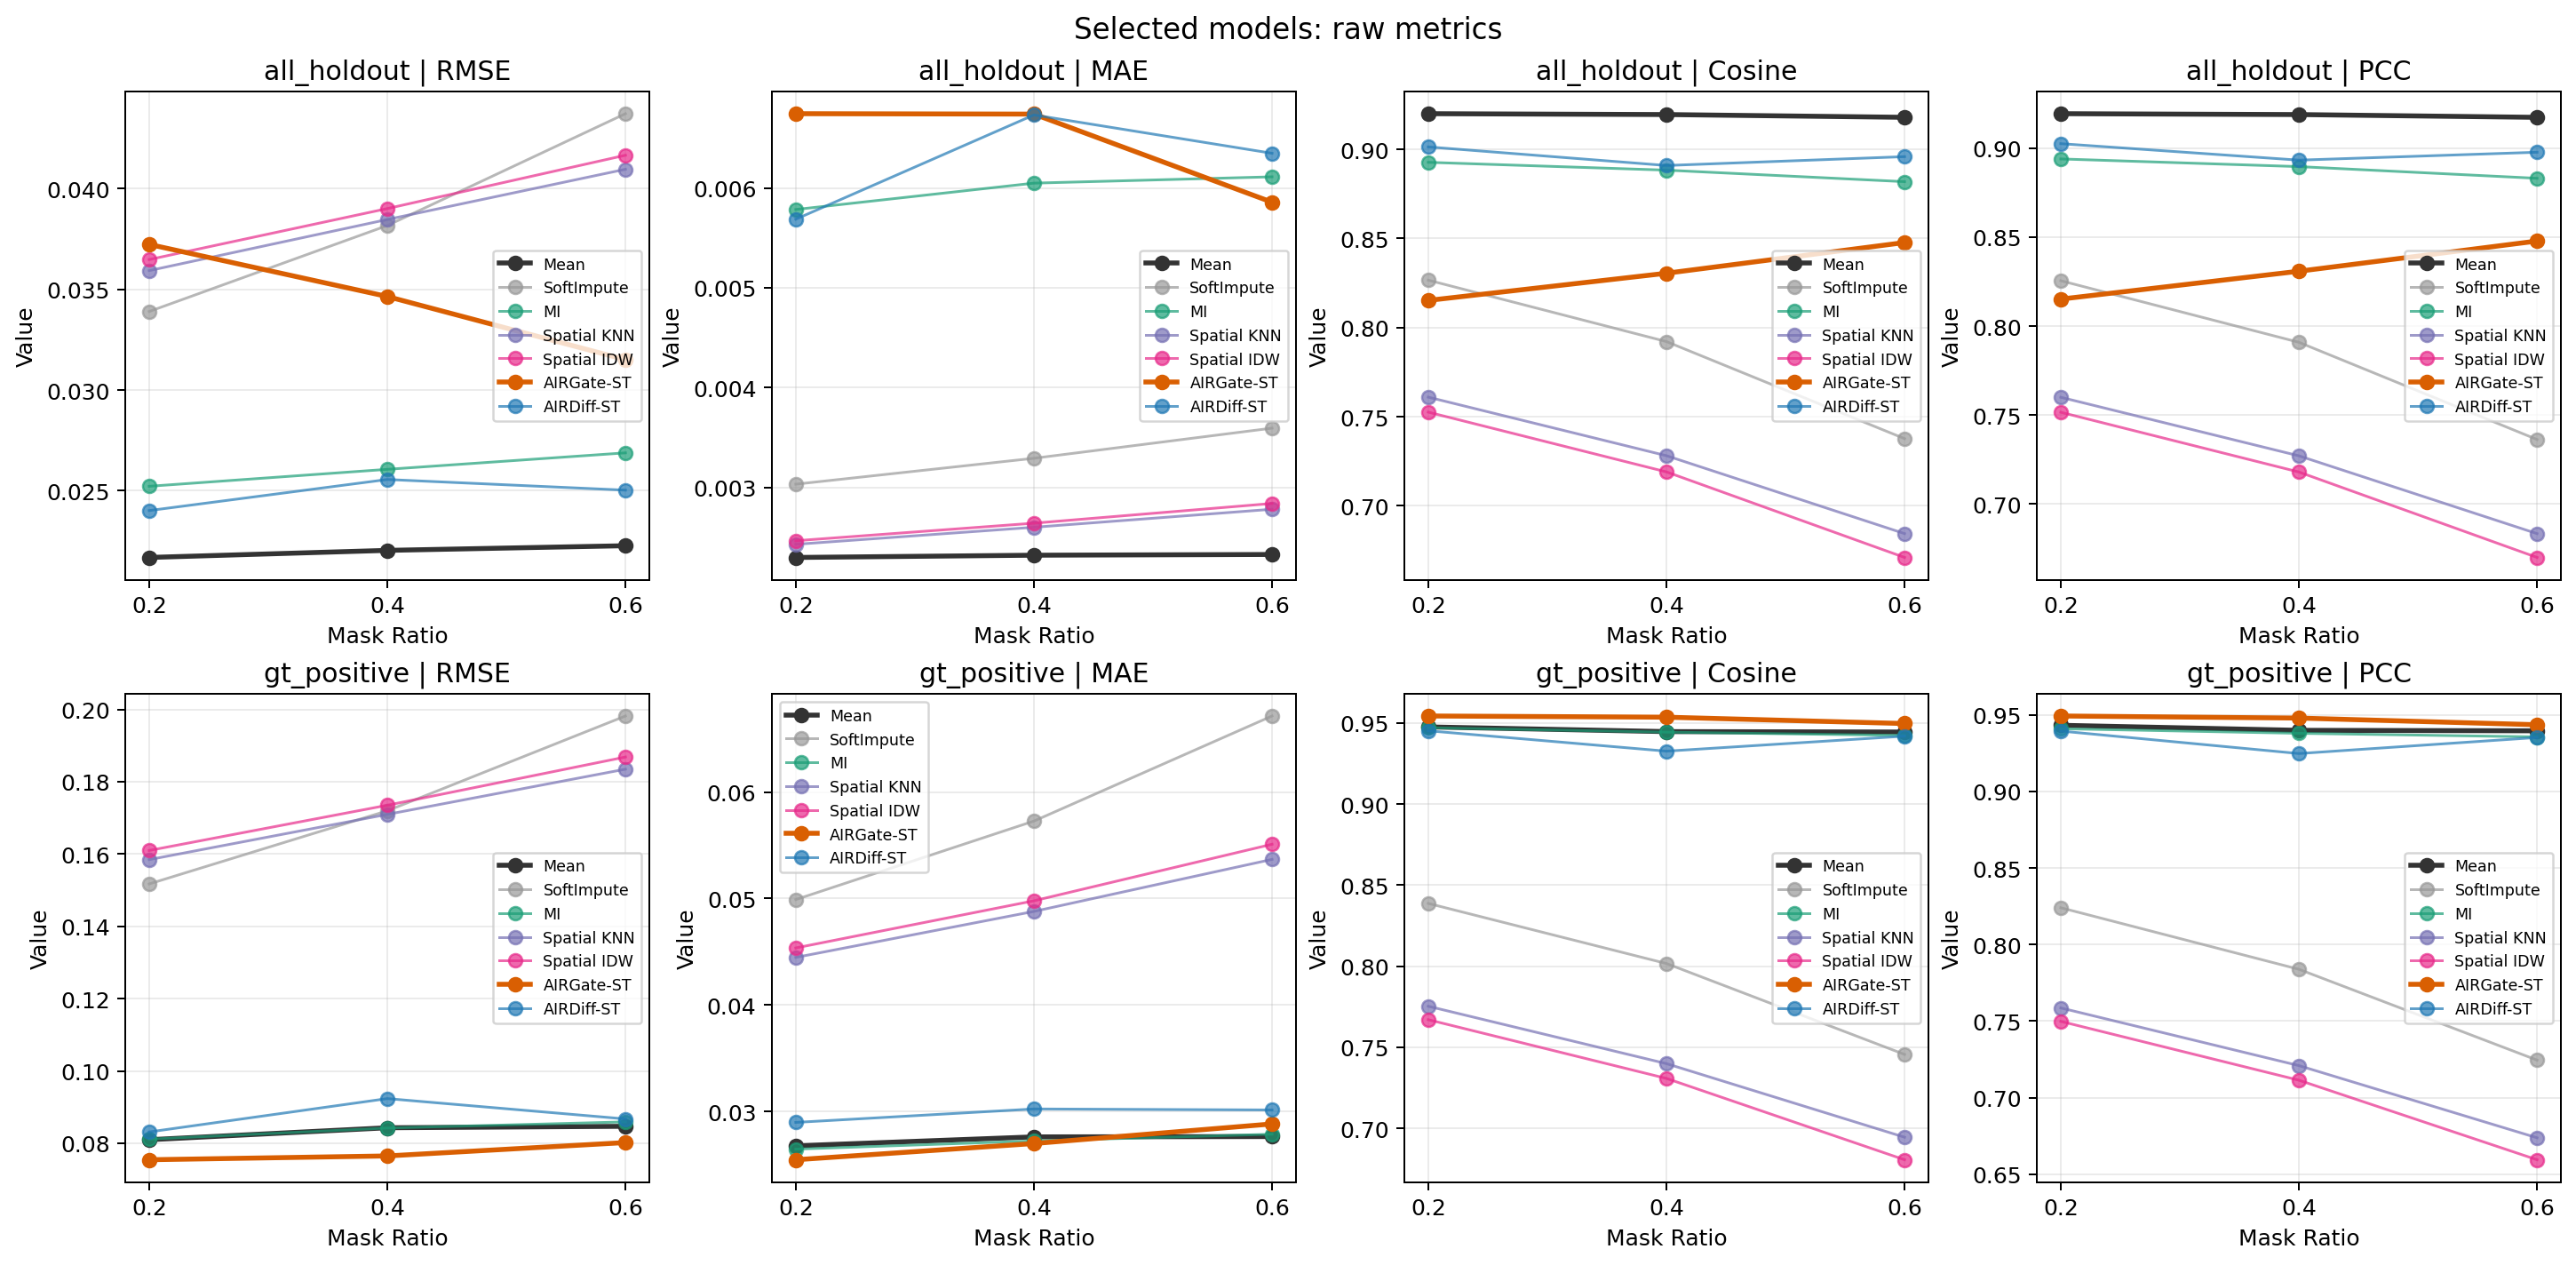

Selected-models mask-ratio summary (head):


,mask_ratio,layer,method,metric,value,rank,signed_improvement_vs_mean
0,20,all_holdout,Mean Baseline,rmse,0.021689,1,0.000000
1,20,all_holdout,SoftImpute,rmse,0.033899,4,-0.012210
2,20,all_holdout,Multiple Imputation,rmse,0.025223,3,-0.003534
3,20,all_holdout,Spatial KNN,rmse,0.035930,5,-0.014241
4,20,all_holdout,Spatial IDW,rmse,0.036479,6,-0.014790
5,20,all_holdout,AIRGate-ST,rmse,0.037231,7,-0.015542
6,20,all_holdout,AIRDiff-ST,rmse,0.024017,2,-0.002328
7,20,all_holdout,Mean Baseline,mae,0.002298,1,0.000000
8,20,all_holdout,SoftImpute,mae,0.003032,4,-0.000734
9,20,all_holdout,Multiple Imputation,mae,0.005784,6,-0.003486



RMSE on gt_positive vs mask_ratio (lower is better):


method,AIRDiff-ST,AIRGate-ST,Mean Baseline,Multiple Imputation,SoftImpute,Spatial IDW,Spatial KNN
mask_ratio,,,,,,,
20,0.0831,0.0754,0.0810,0.0811,0.1517,0.1610,0.1584
40,0.0923,0.0765,0.0843,0.0842,0.1719,0.1735,0.1710
60,0.0867,0.0802,0.0847,0.0859,0.1982,0.1868,0.1835


In [23]:
from IPython.display import Image, display

DEMO_DIR = PROJECT_ROOT / "results" / "notebook_demo"

display(Image(filename=str(DEMO_DIR / "selected_models_raw_lines.png")))

mask_ratio_summary = pd.read_csv(DEMO_DIR / "selected_models_mask_ratio_summary.csv")
print("Selected-models mask-ratio summary (head):")
display(mask_ratio_summary.head(10))

rmse_table = (
    mask_ratio_summary
    .query('layer == "gt_positive" and metric == "rmse"')
    .pivot_table(index="mask_ratio", columns="method", values="value")
)
print("\nRMSE on gt_positive vs mask_ratio (lower is better):")
display(rmse_table.round(4))

## 6. Benchmark Results: Method Comparison Across Datasets

At the 60% holdout point selected in the previous section, the boxplot summarises each method's metric distribution across all 12 prepared datasets. AIRGate-ST and AIRDiff-ST sit at lower RMSE / MAE and higher Cosine / PCC than the matrix and spatial baselines on the `all_holdout` layer, with AIRGate-ST also winning on `gt_positive`.

The PNG below is the pre-rendered output committed under `results/notebook_demo/`. The corresponding summary CSV provides one row per sample x method x layer used to build the boxplot.

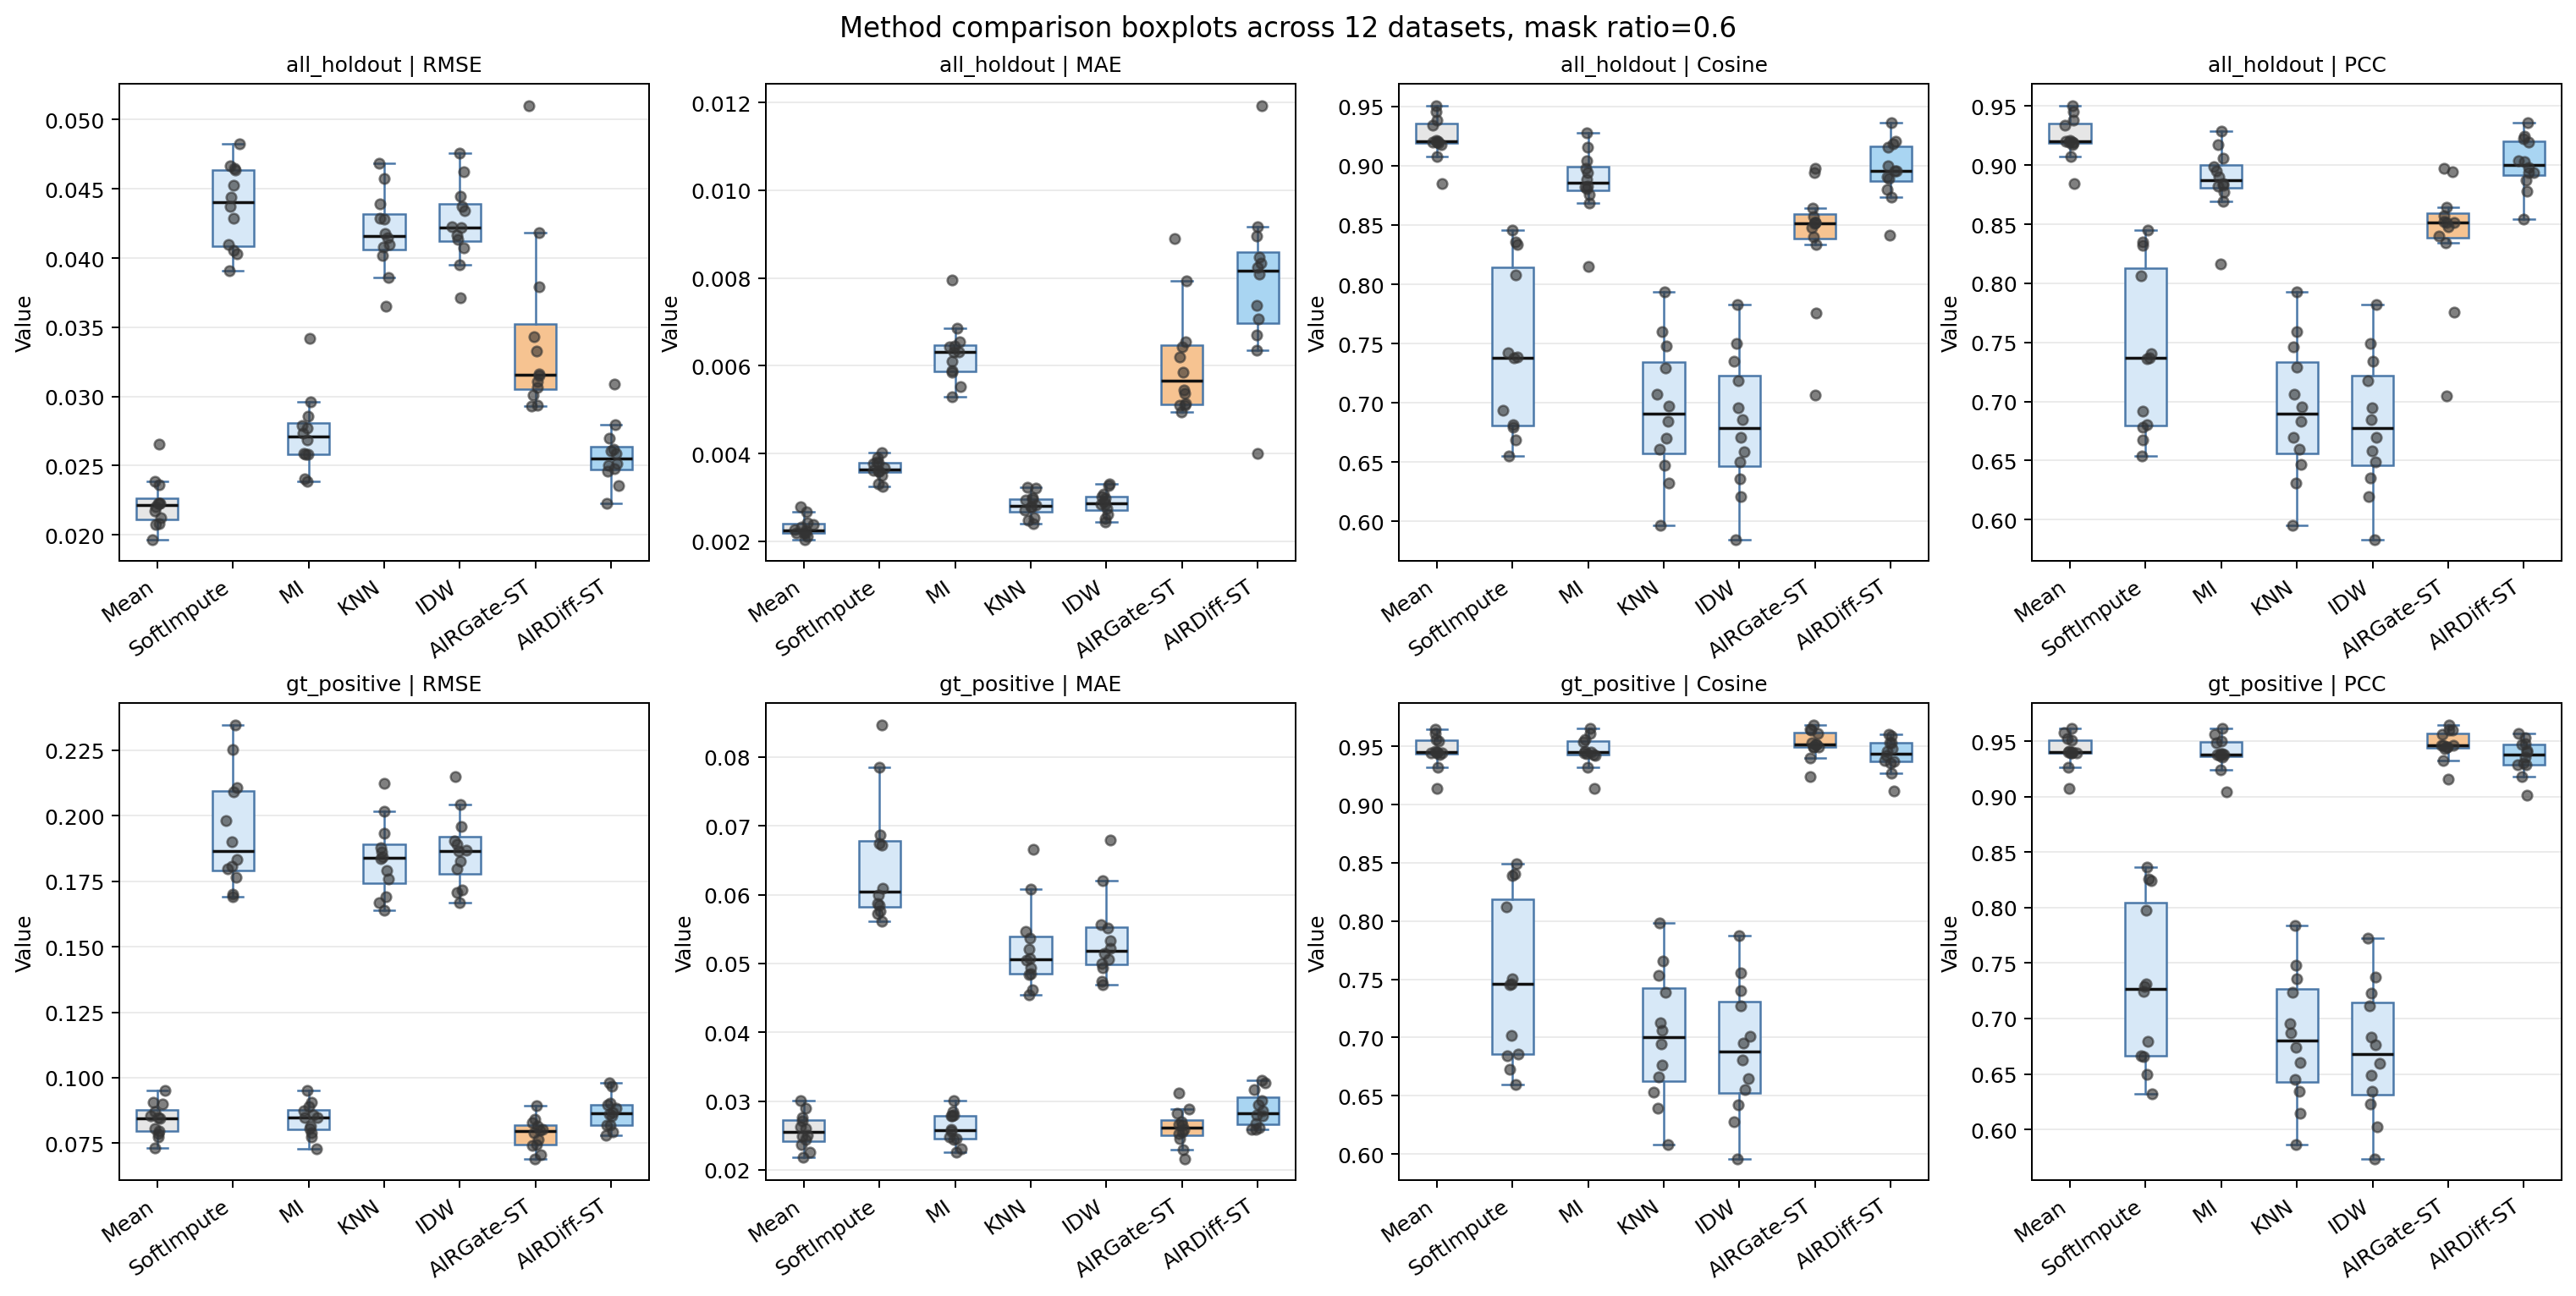

Method-comparison summary (head):


,sample_id,result_dir,mask_ratio,method,layer,n,rmse,mae,cos,pearson_r
0,151507,151507_seed2874_e100_per_site_random_60_seed2874,60,AIRDiff-ST,all_holdout,5992262,0.026993,0.009169,0.880026,0.886952
1,151508,151508_seed2874_e100_per_site_random_60_seed2874,60,AIRDiff-ST,all_holdout,5521560,0.023580,0.006697,0.900159,0.903650
2,151509,151509_seed2874_e100_per_site_random_60_seed2874,60,AIRDiff-ST,all_holdout,6540251,0.025878,0.007059,0.891005,0.893947
3,151510,151510_seed2874_e100_per_site_random_60_seed2874,60,AIRDiff-ST,all_holdout,6234353,0.024789,0.008960,0.895632,0.903046
4,151669,151669_seed1531_e100_per_site_random_60_seed1531,60,AIRDiff-ST,all_holdout,6532881,0.026053,0.008331,0.915567,0.919300
5,151670,151670_seed1531_e100_per_site_random_60_seed1531,60,AIRDiff-ST,all_holdout,4847211,0.022297,0.003992,0.936281,0.936244
6,151671,151671_seed1531_e100_per_site_random_60_seed1531,60,AIRDiff-ST,all_holdout,8501281,0.026192,0.008247,0.918669,0.922365
7,151672,151672_seed1531_e100_per_site_random_60_seed1531,60,AIRDiff-ST,all_holdout,6091389,0.025126,0.008092,0.920609,0.924332
8,151673,seed1531_e100_per_site_random_60_seed1531,60,AIRDiff-ST,all_holdout,6053512,0.025031,0.006347,0.895848,0.897781
9,151674,151674_seed1531_e100_per_site_random_60_seed1531,60,AIRDiff-ST,all_holdout,12791022,0.030886,0.011931,0.841274,0.854253



Per-method median across 12 datasets (mask ratio = 60%, all_holdout layer):


,cos,mae,pearson_r,rmse
method,,,,
AIRDiff-ST,0.8957,0.0082,0.9004,0.0255
AIRGate-ST,0.8517,0.0057,0.8515,0.0316
Mean Baseline,0.9203,0.0023,0.9199,0.0222
Multiple Imputation,0.8857,0.0063,0.8873,0.0271
SoftImpute,0.7380,0.0036,0.7367,0.0441
Spatial IDW,0.6786,0.0029,0.6774,0.0422
Spatial KNN,0.6907,0.0028,0.6895,0.0416


In [24]:
display(Image(filename=str(DEMO_DIR / "method_comparison_boxplots_ratio_60.png")))

boxplot_summary = pd.read_csv(DEMO_DIR / "method_comparison_boxplot_summary.csv")
print("Method-comparison summary (head):")
display(boxplot_summary.head(10))

pivot_all_holdout = (
    boxplot_summary.query('layer == "all_holdout"')
    .pivot_table(index="method",
                 values=["rmse", "mae", "cos", "pearson_r"],
                 aggfunc="median")
)
print("\nPer-method median across 12 datasets (mask ratio = 60%, all_holdout layer):")
display(pivot_all_holdout.round(4))

## 7. Benchmark Results: High-Signal Block Heatmap

The 3x3 panel below shows reconstruction quality on a high-signal observed-only sub-block of sample 151673 at 60% holdout. The block selects 64 spots and 50 sites whose ground-truth ratio crosses 0.05 in many spots, so visual differences between methods are not dominated by zero-inflated entries. Columns are ordered by descending mean GT ratio, so the leftmost columns are the strongest editing signal.

Panel reading order:

| Row | Column 1 | Column 2 | Column 3 |
| --- | --- | --- | --- |
| 1 | GT | Masked Train (gray = held out) | Mean |
| 2 | SoftImpute | MI | Spatial KNN |
| 3 | Spatial IDW | AIRGate-ST | AIRDiff-ST |

The PNG below is the pre-rendered output of `visualization/method_comparison_high_signal_block.py`, committed under `results/notebook_demo/`.

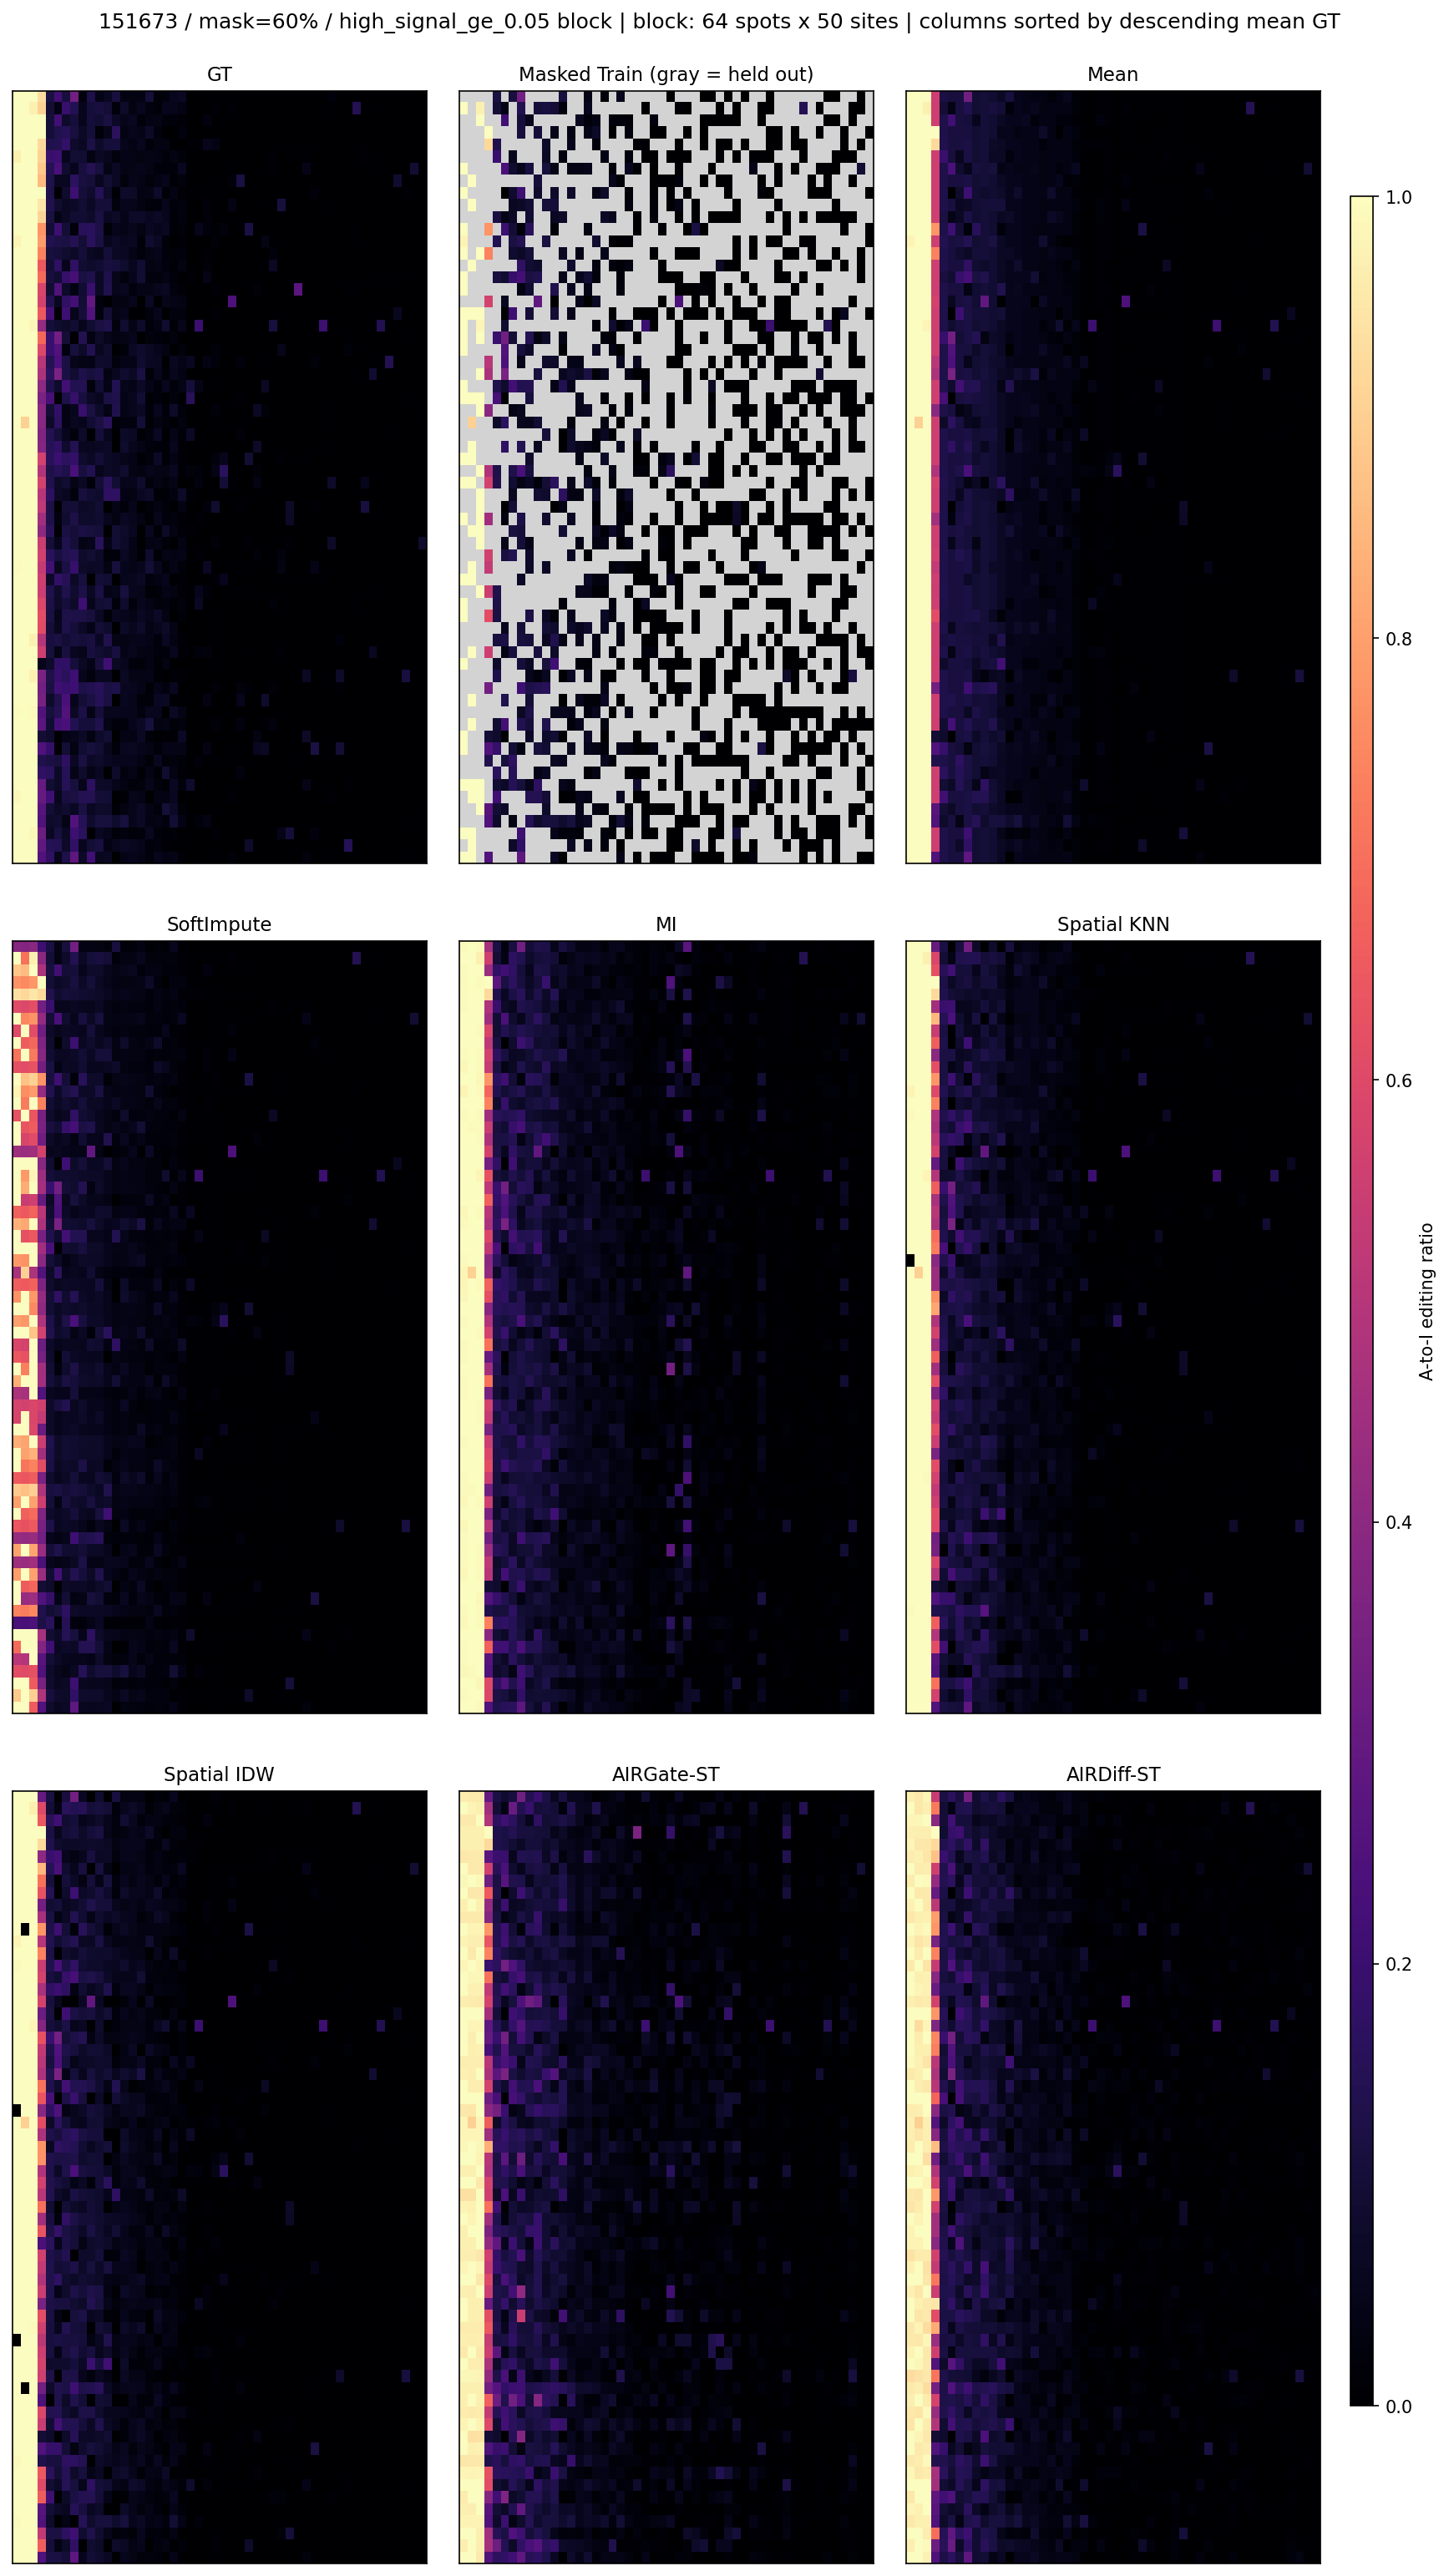

In [25]:
display(Image(filename=str(DEMO_DIR / "151673_60_high_signal_ge_0.05.png")))

## 8. Observations from the Benchmark

The following observations describe how the project's models behave on A-to-I editing data, grounded in the figures and tables from Sections 5-7. They are model-evaluation observations, not biological discoveries; we do not attribute editing patterns to specific genes or regulatory mechanisms.

- Zero-inflation dominates `all_holdout`. On `all_holdout`, Mean Baseline lands near the top because most held-out entries have a true ratio close to zero, and predicting zero everywhere is competitive on RMSE/MAE. Once the layer narrows to `gt_positive`, Mean Baseline's RMSE jumps from roughly 0.022 to roughly 0.085 while AIRGate-ST drops to roughly 0.078. Recovering editing signal therefore requires modelling the gate (probability of editing) separately from the magnitude, not just minimising error against a zero-heavy distribution.

- Pure spatial smoothing is not sufficient on `gt_positive`. Spatial KNN and Spatial IDW reach RMSE around 0.18-0.19 on `gt_positive`, well above AIRGate-ST and AIRDiff-ST (around 0.08). Pure neighbour averaging does not capture the discrete spot-level editing decisions visible in the high-signal block: editing patterns are not smooth across all neighbours but contain sharp transitions, so spatial priors should be combined with site-specific editability rather than applied uniformly.

- Model-based methods degrade more slowly under heavier missingness. As the mask ratio rises from 20% to 60%, AIRGate-ST model extrapolates better when training observations are sparse, the practically relevant regime for spatial transcriptomic editing data where most spot-site pairs are unobserved or have very low coverage.

- The high-signal block recovers intermediate editing levels, not just extremes. In Section 7, AIRGate-ST and AIRDiff-ST produce mid-range (purple) predictions in regions where Spatial KNN, Spatial IDW, and SoftImpute collapse to near-zero. The project models therefore retain quantitative information about partial editing, rather than binarising the prediction into "high" and "zero" classes.

These observations bound what downstream analyses the imputed matrices can support: per-spot editing trends and per-site editability rankings, rather than direct claims about editing-driven cell states. Biological interpretation of specific spatial editing patterns is left to domain-expert review of the imputed outputs and is outside the scope of the artifact.

## 9. Why Prediction Files Are Not Shipped

A single per-method `pred_ratio.npy` for one sample at one mask ratio is roughly 60 MB. The full grid of 12 datasets x 7 methods x 3 holdout ratios would exceed several gigabytes, so the artifact does not commit any `pred_ratio.npy` files.

What is committed under `results/notebook_demo/` instead:

- `selected_models_raw_lines.png` and `selected_models_mask_ratio_summary.csv` (Section 5 inputs).
- `method_comparison_boxplots_ratio_60.png` and `method_comparison_boxplot_summary.csv` (Section 6 inputs).
- `151673_60_high_signal_ge_0.05.png` (Section 7 input). The underlying `gt_ratio.npy` / `train_ratio.npy` / `val_mask.npy` / per-method `pred_ratio.npy` files used to render this PNG are not included for the size reason above.

To regenerate the underlying `pred_ratio.npy` files locally, run the benchmark commands documented in `REPRODUCIBILITY.md` Section 4. Once those `.npy` files exist, all three figures shown above can be regenerated end-to-end by running the corresponding `visualization/*.py` scripts on the resulting run directory.

## 10. Model Interpretation

AIRGate-ST is interpreted through its two-stage prediction mechanism rather than through a generic tabular SHAP workflow. The model decomposes each prediction into an editability gate and an editing-strength ratio:

```text
prediction = gate_probability * conditional_editing_ratio
```

The gate estimates whether a site is likely to be edited in a spot. This is important because A-to-I editing matrices are highly zero-inflated: an observed zero is biologically different from an unobserved entry. The ratio branch then estimates the expected editing level conditional on the entry being editable.

Site-level bias terms provide an interpretable site prior. Sites that are frequently edited in the training observations receive different initial and learned tendencies from sites that are rarely edited. This helps separate site-specific editing propensity from spot-specific spatial variation.

The spatial component uses neighboring spots as local support. AIRGate-ST aggregates spatial KNN information and uses a learned attention gate to adjust editability based on nearby observed context. In practical terms, predictions for spatially coherent editing patterns should be supported by neighboring spots, while training-observed values are preserved exactly in the final prediction matrix.

This mechanism-level interpretation is reported together with layered metrics: `all_holdout` evaluates all held-out observed entries, while `gt_positive` focuses on held-out entries with positive editing signal.

## 11. Interpretation Guide

- `all_holdout` evaluates all held-out observed entries.
- `gt_positive` evaluates held-out entries where the true ratio is greater than zero.
- RMSE and MAE are lower-is-better.
- Cosine and PCC are higher-is-better.
- Originally unobserved entries are excluded from metric scoring.

For complete command-line reproducibility, see `REPRODUCIBILITY.md`.